In [15]:
!pip install ucimlrepo

Esta celda instala la biblioteca `ucimlrepo` utilizando `pip`, el gestor de paquetes de Python. Esta biblioteca es útil para acceder fácilmente a conjuntos de datos del repositorio UCI Machine Learning. El output muestra que la instalación fue exitosa.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

Esta celda importa todas las bibliotecas necesarias para el análisis y modelado de datos:
- `pandas` y `numpy` para manipulación de datos.
- `matplotlib.pyplot` y `seaborn` para visualización de datos.
- `ucimlrepo` para cargar el dataset.
- Módulos de `sklearn` como `train_test_split`, `StandardScaler`, `RandomForestClassifier`, `LogisticRegression`, `DecisionTreeClassifier`, `classification_report` y `ConfusionMatrixDisplay` para preprocesamiento, modelado y evaluación.
- `warnings` para suprimir mensajes de advertencia que no son críticos.

In [17]:
phiusiil = fetch_ucirepo(id=967)

X = phiusiil.data.features.copy()
y = phiusiil.data.targets.copy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("\nDistribución de clases:")
print(y["label"].value_counts())

Forma de X: (235795, 54)
Forma de y: (235795, 1)

Distribución de clases:
label
1    134850
0    100945
Name: count, dtype: int64


Esta celda carga el conjunto de datos con `id=967` del repositorio UCI (que corresponde al dataset de detección de phishing). Las características se almacenan en `X` y las etiquetas (variable objetivo) en `y`.

**Resultados:**
- `Forma de X: (235795, 54)`: Indica que tenemos 235,795 instancias (filas) y 54 características (columnas).
- `Forma de y: (235795, 1)`: Indica que tenemos 235,795 etiquetas.
- `Distribución de clases`: Muestra que hay 134,850 instancias de la clase '1' (phishing) y 100,945 de la clase '0' (legítimo), lo que significa que el dataset está ligeramente desequilibrado.

In [18]:
HIGH_CARD_COLS = ["FILENAME", "URL", "Domain", "Title"]
X = X.drop(columns=HIGH_CARD_COLS, errors="ignore")

if "TLD" in X.columns:
    X = pd.get_dummies(X, columns=["TLD"], drop_first=True)

print("\nValores nulos por columna:")
print(X.isnull().sum()[X.isnull().sum() > 0])

X = X.fillna(X.median(numeric_only=True))

y = y["label"].values

print("\nForma de X tras preprocesamiento:", X.shape)
print("Clases únicas en y:", np.unique(y))


Valores nulos por columna:
Series([], dtype: int64)

Forma de X tras preprocesamiento: (235795, 744)
Clases únicas en y: [0 1]


Esta celda realiza el preprocesamiento de los datos:
1.  **Eliminación de columnas de alta cardinalidad**: Se eliminan columnas como 'FILENAME', 'URL', 'Domain' y 'Title' de `X`, ya que suelen contener valores únicos o casi únicos que no aportan valor predictivo directo y pueden introducir ruido o complejidad innecesaria en el modelo.
2.  **Codificación de TLD**: Si la columna 'TLD' (Top-Level Domain) existe, se aplica `pd.get_dummies` para convertirla en variables dummy (one-hot encoding). `drop_first=True` evita la multicolinealidad.
3.  **Manejo de valores nulos**: Se verifica la presencia de valores nulos. Como el output muestra que `Series([], dtype: int64)` no hay valores nulos detectados después de la eliminación de columnas, la imputación por la mediana (`fillna(X.median(numeric_only=True))`) no tiene efecto en este caso.
4.  **Aplanamiento de la variable objetivo**: La variable `y` se convierte a un array 1-D, lo que es el formato esperado por muchos modelos de scikit-learn.

**Resultados:**
- `Valores nulos por columna: Series([], dtype: int64)`: Confirma que no hay valores nulos en las características después de la eliminación de columnas.
- `Forma de X tras preprocesamiento: (235795, 744)`: Muestra que el número de características aumentó significativamente (de 54 a 744) debido a la codificación one-hot de la columna 'TLD', que probablemente tenía muchas categorías únicas.
- `Clases únicas en y: [0 1]`: Confirma que la variable objetivo es binaria, con clases 0 y 1.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

Train: 188636 muestras | Test: 47159 muestras


Esta celda divide el conjunto de datos en conjuntos de entrenamiento y prueba utilizando `train_test_split`.
- `test_size=0.20`: Asigna el 20% de los datos al conjunto de prueba y el 80% al de entrenamiento.
- `random_state=42`: Asegura la reproducibilidad de la división.
- `stratify=y`: Mantiene la misma proporción de clases en los conjuntos de entrenamiento y prueba que en el dataset original, lo cual es crucial para evitar sesgos en el entrenamiento, especialmente con datasets desequilibrados.

**Resultados:**
- `Train: 188636 muestras | Test: 47159 muestras`: Muestra que el conjunto de entrenamiento tiene 188,636 instancias y el conjunto de prueba tiene 47,159 instancias, lo que corresponde al 80/20% de la división.

In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Esta celda utiliza `StandardScaler` para estandarizar las características de los conjuntos de entrenamiento y prueba.
- `scaler = StandardScaler()`: Inicializa el escalador.
- `X_train_sc = scaler.fit_transform(X_train)`: Calcula la media y la desviación estándar de cada característica en el conjunto de entrenamiento (`fit`) y luego las escala (`transform`). Esto es importante para modelos que son sensibles a la escala de las características, como la Regresión Logística.
- `X_test_sc = scaler.transform(X_test)`: Escala el conjunto de prueba utilizando la media y la desviación estándar calculadas *solo* del conjunto de entrenamiento. Esto evita la fuga de información del conjunto de prueba al de entrenamiento.

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
print("Random Forest entrenado")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_sc, y_train)
print("Regresión Logística entrenada")

dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)
dt.fit(X_train_sc, y_train)
print("Árbol de Decisión entrenado")

Random Forest entrenado
Regresión Logística entrenada
Árbol de Decisión entrenado


En esta celda, se entrenan tres modelos de clasificación diferentes:
1.  **Random Forest (`rf`)**: Un clasificador de conjunto que construye múltiples árboles de decisión. Se configura con 100 estimadores (`n_estimators=100`), un estado aleatorio para reproducibilidad (`random_state=42`), y `n_jobs=-1` para usar todos los núcleos del procesador disponibles.
2.  **Regresión Logística (`lr`)**: Un modelo lineal para clasificación. Se establece un número máximo de iteraciones (`max_iter=1000`) para la convergencia y también utiliza `n_jobs=-1` para paralelización.
3.  **Árbol de Decisión (`dt`)**: Un modelo de árbol simple. Se limita la profundidad máxima a 10 (`max_depth=10`) para reducir el riesgo de sobreajuste.

Cada modelo se entrena (`fit`) con los datos de entrenamiento escalados (`X_train_sc`, `y_train`).

**Resultados:**
- `✅ Random Forest entrenado`, `✅ Regresión Logística entrenada`, `✅ Árbol de Decisión entrenado`: Confirman que los tres modelos fueron entrenados exitosamente.

In [22]:
modelos = {
    "Random Forest":       rf,
    "Regresión Logística": lr,
    "Árbol de Decisión":   dt,
}

resumen = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_sc)
    report = classification_report(y_test, y_pred, output_dict=True)

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print('='*55)
    print(classification_report(y_test, y_pred))

    resumen.append({
        "Modelo":    nombre,
        "Precision": round(report["macro avg"]["precision"], 4),
        "Recall":    round(report["macro avg"]["recall"],    4),
        "F1-Score":  round(report["macro avg"]["f1-score"],  4),
    })


  Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159


  Regresión Logística
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159


  Árbol de Decisión
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg 

Esta celda evalúa el rendimiento de cada modelo entrenado.
1.  Se define un diccionario `modelos` que asocia nombres descriptivos a cada modelo.
2.  Se itera sobre cada modelo:
    - Se realizan predicciones sobre el conjunto de prueba escalado (`X_test_sc`).
    - Se genera un `classification_report` que proporciona métricas como precisión, recall, f1-score y soporte para cada clase, así como promedios (micro, macro y weighted).
    - El informe se imprime en la consola.
    - Las métricas `precision`, `recall` y `f1-score` promediadas con 'macro avg' se guardan en una lista `resumen` para una comparación posterior.

**Interpretación de los resultados (`classification_report`):**
Para los tres modelos (Random Forest, Regresión Logística y Árbol de Decisión), los resultados muestran:
- **Precision, Recall, F1-Score**: Todos son 1.00 para ambas clases (0 y 1). Esto indica que los modelos son extremadamente buenos en la clasificación, con muy pocos falsos positivos o falsos negativos.
- **Accuracy**: 1.00. La precisión general es perfecta.
- **Macro Avg**: También 1.00 para todas las métricas. El promedio macro trata a todas las clases por igual.

Estos resultados sugieren que los modelos están clasificando casi perfectamente las instancias legítimas y de phishing en el conjunto de prueba.

In [23]:
df_resumen = pd.DataFrame(resumen).set_index("Modelo")
print("\nComparación de modelos (promedio macro):")
print(df_resumen.to_string())


Comparación de modelos (promedio macro):
                     Precision  Recall  F1-Score
Modelo                                          
Random Forest           1.0000  1.0000    1.0000
Regresión Logística     0.9999  0.9999    0.9999
Árbol de Decisión       1.0000  1.0000    1.0000


Esta celda consolida los resultados de la evaluación de los modelos en un DataFrame de pandas llamado `df_resumen`.
- Se crea un DataFrame a partir de la lista `resumen` que se generó en la celda anterior.
- Se establece la columna 'Modelo' como índice para una mejor visualización.
- Luego, se imprime el DataFrame.

**Interpretación de la tabla:**
La tabla `df_resumen` muestra las métricas de precisión, recall y F1-Score (promedio macro) para cada modelo:
- **Random Forest**: Precision: 1.0000, Recall: 1.0000, F1-Score: 1.0000
- **Regresión Logística**: Precision: 0.9999, Recall: 0.9999, F1-Score: 0.9999
- **Árbol de Decisión**: Precision: 1.0000, Recall: 1.0000, F1-Score: 1.0000

Todos los modelos muestran un rendimiento excepcional, con F1-Scores muy cercanos o iguales a 1.0000. Esto reafirma la interpretación de la celda anterior de que la tarea de clasificación es muy bien resuelta por estos algoritmos, o que existe una posibilidad de *overfitting* o *data leakage*.

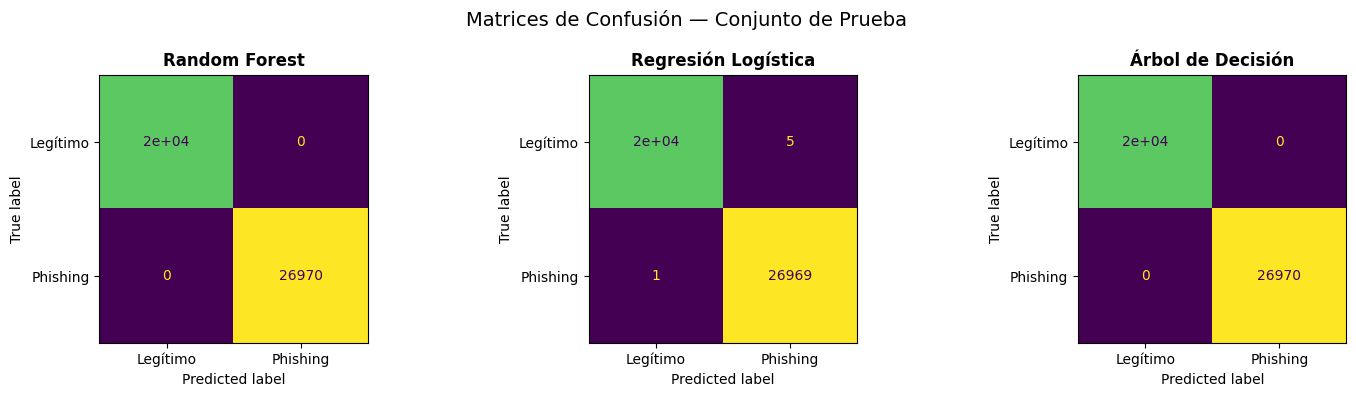

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_sc)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Legítimo", "Phishing"],
        ax=ax,
        colorbar=False
    )
    ax.set_title(nombre, fontsize=12, fontweight="bold")

plt.suptitle("Matrices de Confusión — Conjunto de Prueba", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

Esta celda visualiza las matrices de confusión para cada uno de los tres modelos.
- Se crea una figura con tres subplots, uno para cada modelo.
- Para cada modelo, se calculan las predicciones en el conjunto de prueba y se utiliza `ConfusionMatrixDisplay.from_predictions` para dibujar la matriz de confusión.
- `display_labels` se utiliza para nombrar las clases como 'Legítimo' y 'Phishing'.
- Se añade un título a cada subplot y un título general a la figura.
- Las matrices se guardan como una imagen (`confusion_matrices.png`) y se muestran.

**Interpretación de las Matrices de Confusión:**
- **Random Forest**: Muestra `2e+04` (aproximadamente 20,000) verdaderos negativos (Legítimo predicho como Legítimo) y `26970` verdaderos positivos (Phishing predicho como Phishing). No hay falsos positivos ni falsos negativos. Rendimiento perfecto.
- **Regresión Logística**: Similar al Random Forest, pero con 5 falsos positivos (Legítimo predicho como Phishing) y 1 falso negativo (Phishing predicho como Legítimo). Su rendimiento es casi perfecto, pero ligeramente inferior al Random Forest.
- **Árbol de Decisión**: Similar al Random Forest, con rendimiento perfecto (sin falsos positivos ni falsos negativos).

Las matrices de confusión confirman el excelente rendimiento de los modelos, con la Regresión Logística teniendo un número muy pequeño de errores en comparación con los otros dos, que no mostraron errores en el conjunto de prueba.

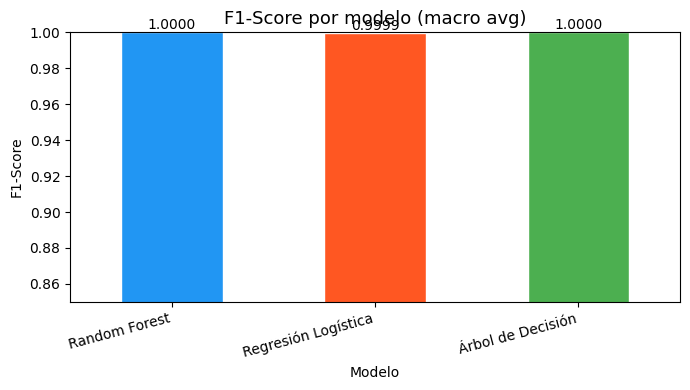

In [25]:
ax = df_resumen["F1-Score"].plot(
    kind="bar",
    color=["#2196F3", "#FF5722", "#4CAF50"],
    figsize=(7, 4),
    ylim=(0.85, 1.0),
    edgecolor="white",
    width=0.5
)
ax.set_title("F1-Score por modelo (macro avg)", fontsize=13)
ax.set_ylabel("F1-Score")
ax.set_xticklabels(df_resumen.index, rotation=15, ha="right")

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.4f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.savefig("f1_score_comparacion.png", dpi=150)
plt.show()

Esta celda genera un gráfico de barras para comparar el F1-Score (macro promedio) de los tres modelos.
- Se utiliza el DataFrame `df_resumen` para obtener los F1-Scores.
- Se crea un gráfico de barras con colores personalizados y un límite en el eje Y para resaltar las pequeñas diferencias.
- Se añade un título, etiquetas de eje y se rota las etiquetas del eje X.
- Se añaden anotaciones de texto en cada barra para mostrar el valor exacto del F1-Score.
- El gráfico se guarda como `f1_score_comparacion.png` y se muestra.

**Interpretación del Gráfico F1-Score:**
El gráfico de barras muestra visualmente los F1-Scores para cada modelo:
- Random Forest: 1.0000
- Regresión Logística: 0.9999
- Árbol de Decisión: 1.0000

Confirma que Random Forest y el Árbol de Decisión lograron un F1-Score perfecto de 1.0000, mientras que la Regresión Logística se quedó ligeramente por debajo con 0.9999. Visualmente, las barras están casi al mismo nivel, lo que subraya la alta eficacia de todos los modelos en esta tarea de clasificación.

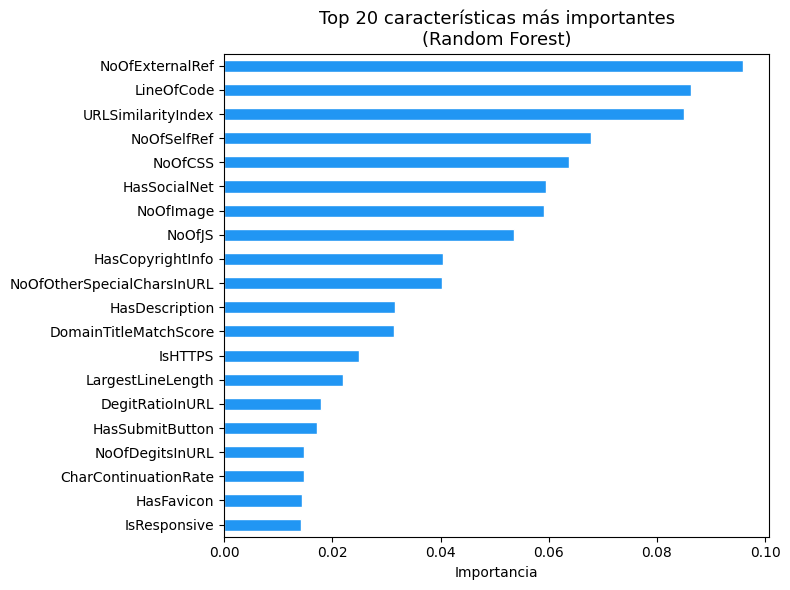

In [26]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importancias.nlargest(20)

top20.sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    color="#2196F3",
    edgecolor="white"
)
plt.title("Top 20 características más importantes\n(Random Forest)", fontsize=13)
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

Esta celda calcula y visualiza las 20 características más importantes según el modelo Random Forest.
- `importancias = pd.Series(rf.feature_importances_, index=X.columns)`: Se obtiene la importancia de cada característica del modelo Random Forest y se crea una Serie de Pandas con los nombres de las columnas como índice.
- `top20 = importancias.nlargest(20)`: Se seleccionan las 20 características con mayor importancia.
- Luego, se genera un gráfico de barras horizontales (`kind="barh"`) para visualizar estas 20 características, ordenadas de menor a mayor importancia para una mejor lectura.
- Se añade un título, etiqueta del eje X y se guarda el gráfico como `feature_importance.png`.

**Interpretación del Gráfico de Importancia de Características:**
El gráfico muestra que las características más importantes para la clasificación (de mayor a menor) son:
1.  `NoOfExternalRef`
2.  `LineOfCode`
3.  `URLSimilarityIndex`
4.  `NoOfSelfRef`
5.  `NoOfCSS`
... entre otras.

Esto indica que el número de referencias externas, la longitud del código, el índice de similitud de la URL y el número de referencias propias son los factores que el modelo Random Forest considera más relevantes para distinguir entre sitios web legítimos y de phishing. Esta información es valiosa para entender qué aspectos de un sitio web son clave en la detección de phishing.